<a href="https://colab.research.google.com/github/Singleeee/T1-IA-Regressao/blob/main/Regression_limpo_novo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

drive.mount('/content/drive')
!find /content/drive -name "bottle.csv"

# Configurações visuais do Matplotlib
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/bottle.csv


In [15]:
# Carregamento do dataset CalCOFI (ajuste o caminho se necessário)
caminho = "/content/drive/MyDrive/bottle.csv"
df = pd.read_csv(caminho, low_memory=False)

# Seleção dos atributos e remoção de valores nulos
colunas = ['Depthm', 'T_degC', 'O2ml_L', 'Salnty', 'STheta']
df_clean = df[colunas].dropna().reset_index(drop=True)

print(f"Dataset carregado com sucesso. Total de amostras limpas: {len(df_clean)}")
df_clean.head()

Dataset carregado com sucesso. Total de amostras limpas: 661268


,Depthm,T_degC,O2ml_L,Salnty,STheta
0,0,10.30,5.90,33.030,25.364
1,6,18.46,6.02,32.920,23.568
2,10,10.29,6.04,32.951,25.304
3,15,10.29,6.06,32.990,25.335
4,20,10.33,6.04,33.005,25.339


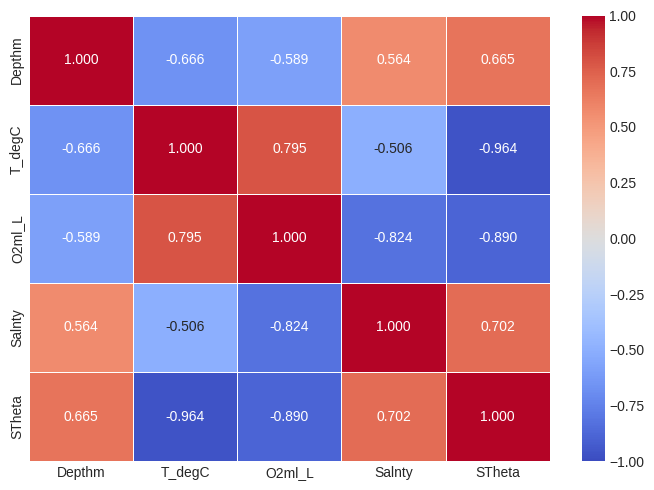

In [16]:
# Cálculo da matriz de correlação
matriz_corr = df_clean.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

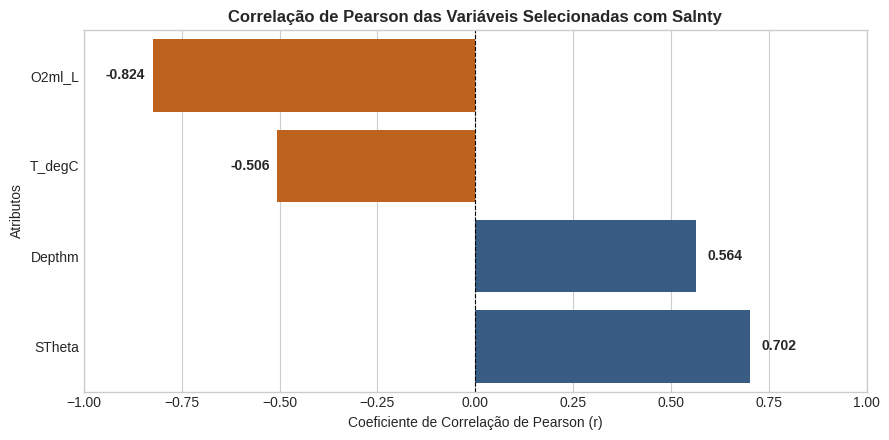

In [17]:
# 1. Seleção exclusiva das variáveis do projeto
colunas_projeto = ['Depthm', 'T_degC', 'O2ml_L', 'Salnty', 'STheta']
df_projeto = df[colunas_projeto].dropna()

# 2. Cálculo da correlação de Pearson de cada variável com 'Salnty'
corr_salnty = df_projeto.corr()['Salnty'].drop('Salnty').sort_values(ascending=True)

# 3. Plotagem do gráfico de barras horizontais
plt.figure(figsize=(9, 4.5))

# Cores: azul para correlação positiva, vermelho/laranja para correlação negativa
cores = ['#d95f02' if val < 0 else '#2b5c8f' for val in corr_salnty.values]

ax = sns.barplot(
    x=corr_salnty.values,
    y=corr_salnty.index,
    palette=cores,
    hue=corr_salnty.index,
    legend=False
)

# Linha de referência no zero
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

# Configurações visuais do gráfico
plt.title('Correlação de Pearson das Variáveis Selecionadas com Salnty', fontsize=12, fontweight='bold')
plt.xlabel('Coeficiente de Correlação de Pearson (r)')
plt.ylabel('Atributos')
plt.xlim(-1.0, 1.0)

# Rótulos com os valores exatos ao lado das barras
for i, v in enumerate(corr_salnty.values):
    offset = 0.03 if v >= 0 else -0.12
    ax.text(v + offset, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('correlacao_atributos_selecionados.png', dpi=300)
plt.show()

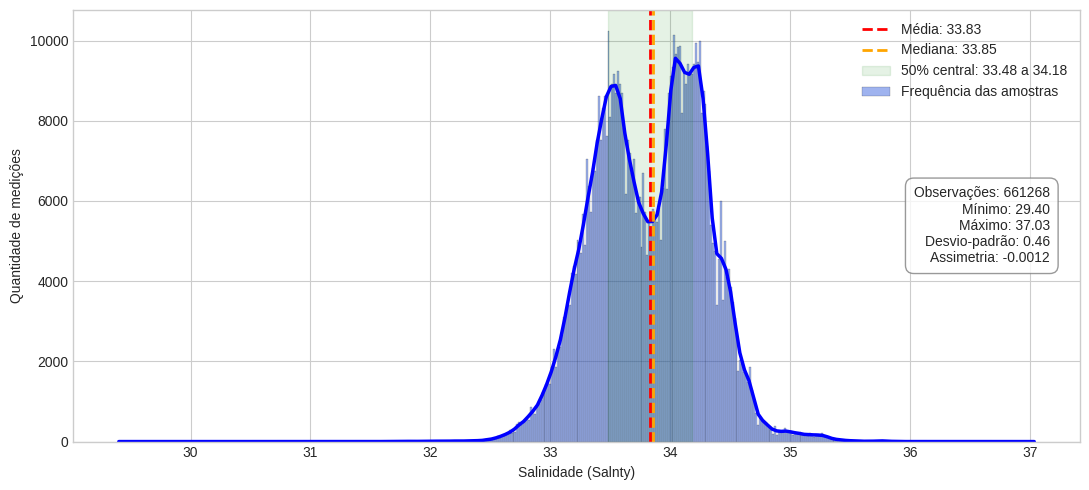

In [18]:
y_target = df_clean['Salnty']

media = y_target.mean()
mediana = y_target.median()
q25, q75 = np.percentile(y_target, [25, 75])

fig, ax = plt.subplots(figsize=(11, 5))

# Histograma e KDE
sns.histplot(y_target, kde=True, color='royalblue', stat="count", ax=ax, label='Frequência das amostras')
ax.lines[0].set_color('blue')
ax.lines[0].set_linewidth(2.5)

# Linhas de tendência central
ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.2f}')
ax.axvline(mediana, color='orange', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.2f}')
ax.axvspan(q25, q75, color='green', alpha=0.1, label=f'50% central: {q25:.2f} a {q75:.2f}')

ax.set_title('', fontsize=13, fontweight='bold')
ax.set_xlabel('Salinidade (Salnty)')
ax.set_ylabel('Quantidade de medições')

texto_stats = (f"Observações: {len(y_target)}\n"
               f"Mínimo: {y_target.min():.2f}\n"
               f"Máximo: {y_target.max():.2f}\n"
               f"Desvio-padrão: {y_target.std():.2f}\n"
               f"Assimetria: {y_target.skew():.4f}")

ax.text(0.97, 0.5, texto_stats, transform=ax.transAxes, fontsize=10,
        verticalalignment='center', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='gray', alpha=0.8))

ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


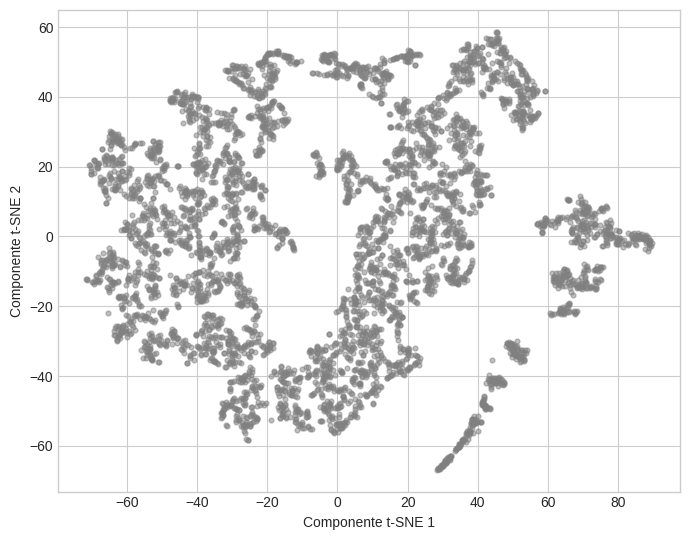

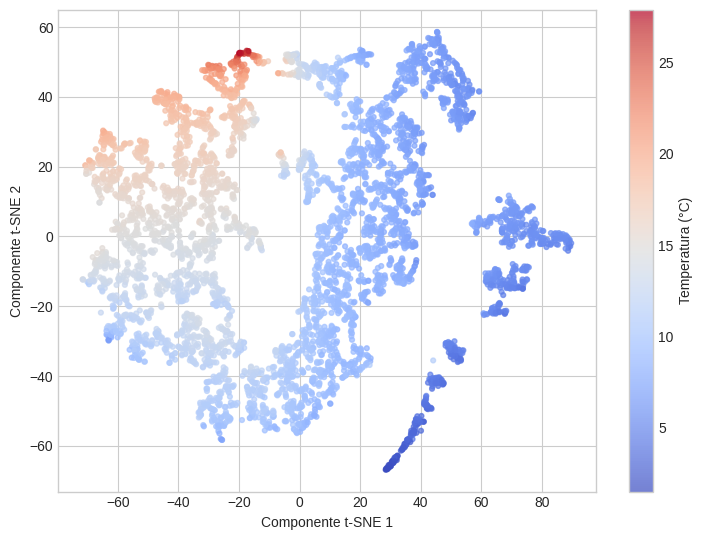

In [19]:
# [Célula 5] Análise Exploratória 3: Clusterização Visual via t-SNE (Imagens Separadas)

# 1. Amostra de 5.000 pontos e padronização
df_sample = df_clean.sample(n=5000, random_state=42)
X_sample_scaled = StandardScaler().fit_transform(df_sample)

# 2. Processamento do t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample_scaled)


# --- IMAGEM 1: Projeção Sem Rótulos ---
plt.figure(figsize=(7, 5.5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, c='gray', s=12)
plt.title('', fontsize=11, fontweight='bold')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.tight_layout()
plt.show()


# --- IMAGEM 2: Projeção Com Rótulos (Colorido por Temperatura) ---
plt.figure(figsize=(7.5, 5.5))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df_sample['T_degC'], cmap='coolwarm', alpha=0.7, s=12)
plt.title('', fontsize=11, fontweight='bold')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.colorbar(scatter, label='Temperatura (°C)')
plt.tight_layout()
plt.show()

In [20]:
X = df_clean[['T_degC', 'O2ml_L']].values
y = df_clean['Salnty'].values.reshape(-1, 1)

# Divisão 80/20
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Padronização Z-score das variáveis explicativas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Adicionando a coluna de Bias (1s) para a formulação matricial: X_b = [1, x1, x2]
X_b_train = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_b_test = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

print(f"Treino: {X_b_train.shape} | Teste: {X_b_test.shape}")

Treino: (529014, 3) | Teste: (132254, 3)


In [21]:
def ridge_regression_fit(X, y, l2_penalty=1.0):
    """
    Fórmula da Equação Normal com Regularização Ridge (L2):
    theta = (X^T * X + lambda * I)' * X^T * y
    """
    n_features = X.shape[1]
    I = np.eye(n_features)
    I[0, 0] = 0  # Não regularizar o termo de bias (intercepto)

    theta = np.linalg.inv(X.T.dot(X) + l2_penalty * I).dot(X.T).dot(y)
    return theta

# Treinamento do modelo Ridge do Zero (lambda = 1.0)
lambda_ridge = 1.0
theta_ridge = ridge_regression_fit(X_b_train, y_train, l2_penalty=lambda_ridge)

y_pred_ridge = X_b_test.dot(theta_ridge)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("=== REGRESSÃO RIDGE (DO ZERO - EQUAÇÃO NORMAL) ===")
print(f"Theta 0 (Intercepto): {theta_ridge[0][0]:.4f}")
print(f"Theta 1 (T_degC):     {theta_ridge[1][0]:.4f}")
print(f"Theta 2 (O2ml_L):     {theta_ridge[2][0]:.4f}")
print(f"R²:  {r2_ridge:.4f}")
print(f"MSE: {mse_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")

=== REGRESSÃO RIDGE (DO ZERO - EQUAÇÃO NORMAL) ===
Theta 0 (Intercepto): 33.8325
Theta 1 (T_degC):     0.1870
Theta 2 (O2ml_L):     -0.5284
R²:  0.7401
MSE: 0.0549
RMSE: 0.2344


In [22]:
def gradient_descent(X, y, alpha=0.01, epochs=500):
    m = len(y)
    n_features = X.shape[1]
    theta = np.zeros((n_features, 1)) # Inicialização dos pesos com zero
    cost_history = []

    for epoch in range(epochs):
        predictions = X.dot(theta)
        errors = predictions - y

        # Derivada da função de custo MSE: (2/m) * X^T * (X*theta - y)
        gradients = (2/m) * X.T.dot(errors)

        # Atualização dos parâmetros
        theta = theta - alpha * gradients

        # Cálculo do custo MSE na época
        cost = np.mean(errors ** 2)
        cost_history.append(cost)

    return theta, cost_history

# Treinamento com alpha=0.1 e 500 épocas
alpha_opt = 0.1
epochs_opt = 500
theta_gd, history_gd = gradient_descent(X_b_train, y_train, alpha=alpha_opt, epochs=epochs_opt)

y_pred_gd = X_b_test.dot(theta_gd)

mse_gd = mean_squared_error(y_test, y_pred_gd)
rmse_gd = np.sqrt(mse_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("=== GRADIENT DESCENT (DO ZERO) ===")
print(f"Theta 0 (Intercepto): {theta_gd[0][0]:.4f}")
print(f"Theta 1 (T_degC):     {theta_gd[1][0]:.4f}")
print(f"Theta 2 (O2ml_L):     {theta_gd[2][0]:.4f}")
print(f"R²:  {r2_gd:.4f}")
print(f"MSE: {mse_gd:.4f}")
print(f"RMSE: {rmse_gd:.4f}")

=== GRADIENT DESCENT (DO ZERO) ===
Theta 0 (Intercepto): 33.8325
Theta 1 (T_degC):     0.1870
Theta 2 (O2ml_L):     -0.5284
R²:  0.7401
MSE: 0.0549
RMSE: 0.2344


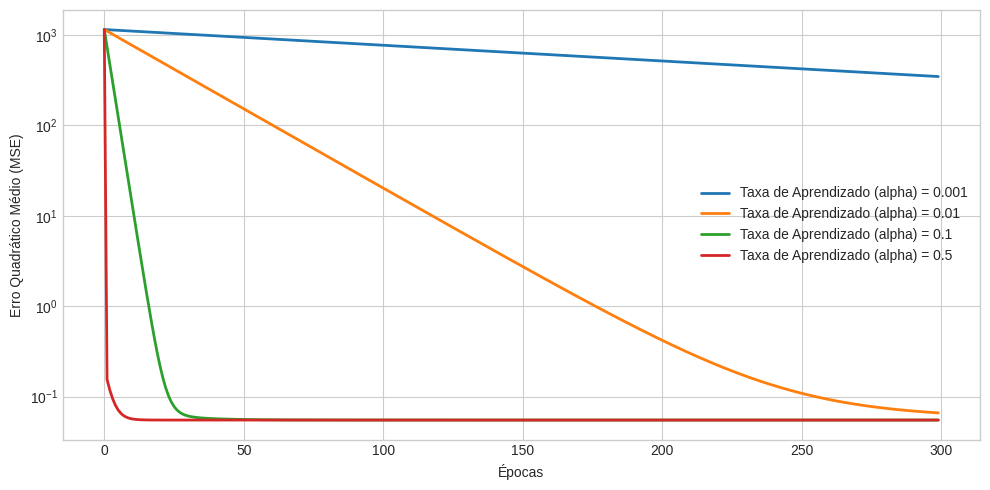

In [23]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
epochs_exp = 300

plt.figure(figsize=(10, 5))

for lr in learning_rates:
    _, cost_hist = gradient_descent(X_b_train, y_train, alpha=lr, epochs=epochs_exp)
    plt.plot(range(epochs_exp), cost_hist, label=f'Taxa de Aprendizado (alpha) = {lr}', linewidth=2)

plt.title('', fontsize=12, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.yscale('log') # Escala logarítmica para melhor visualização da queda do erro
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Tabela comparativa final
tabela_dados = {
    'Modelo / Algoritmo': ['Ridge (Equação Normal)', 'Gradient Descent (DO ZERO)'],
    'Intercepto (theta_0)': [f"{theta_ridge[0][0]:.4f}", f"{theta_gd[0][0]:.4f}"],
    'Peso T_degC (theta_1)': [f"{theta_ridge[1][0]:.4f}", f"{theta_gd[1][0]:.4f}"],
    'Peso O2ml_L (theta_2)': [f"{theta_ridge[2][0]:.4f}", f"{theta_gd[2][0]:.4f}"],
    'R² (Teste)': [f"{r2_ridge:.4f}", f"{r2_gd:.4f}"],
    'MSE (Teste)': [f"{mse_ridge:.4f}", f"{mse_gd:.4f}"],
    'RMSE (Teste)': [f"{rmse_ridge:.4f}", f"{rmse_gd:.4f}"]
}

df_comparativo = pd.DataFrame(tabela_dados)
display(df_comparativo)

,Modelo / Algoritmo,Intercepto (theta_0),Peso T_degC (theta_1),Peso O2ml_L (theta_2),R² (Teste),MSE (Teste),RMSE (Teste)
0,Ridge (Equação Normal),33.8325,0.1870,-0.5284,0.7401,0.0549,0.2344
1,Gradient Descent (DO ZERO),33.8325,0.1870,-0.5284,0.7401,0.0549,0.2344


# Valores reais vs preditos

=== AMOSTRA COMPARATIVA: VALORES REAIS VS. PREDITOS ===


,Salinidade Real (y),Salinidade Predita (ŷ),Erro Absoluto (|y - ŷ|)
0,33.103,33.4825,0.3795
1,33.914,33.5939,0.3201
2,33.770,33.8710,0.1010
3,34.163,34.2630,0.1000
4,33.205,33.3005,0.0955
5,33.305,33.5860,0.2810
6,34.631,33.7761,0.8549
7,34.250,34.3237,0.0737
8,33.384,33.4817,0.0977
9,33.652,33.5513,0.1007


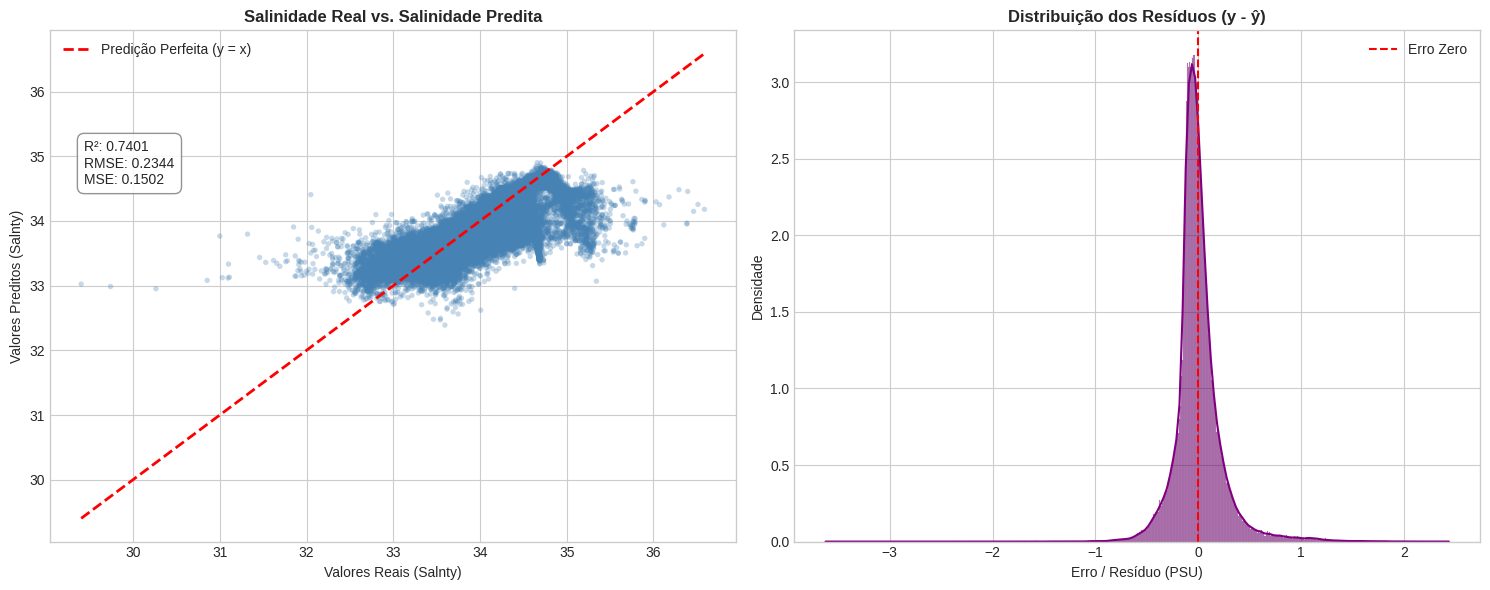

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Ajuste das dimensões dos vetores e cálculo dos resíduos
y_true_flat = y_test.ravel()
y_pred_flat = y_pred_ridge.ravel()
residuos = y_true_flat - y_pred_flat

rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
mae = mean_absolute_error(y_true_flat, y_pred_flat)
r2 = r2_score(y_true_flat, y_pred_flat)

# 2. Exibição de Tabela Comparativa (Primeiras 10 medições de teste)
df_comparacao = pd.DataFrame({
    'Salinidade Real (y)': y_true_flat,
    'Salinidade Predita (ŷ)': y_pred_flat,
    'Erro Absoluto (|y - ŷ|)': np.abs(residuos)
})

print("=== AMOSTRA COMPARATIVA: VALORES REAIS VS. PREDITOS ===")
display(df_comparacao.head(10).round(4))

# 3. Plotagem Visual: Dispersion (Real vs. Predito) + Histograma dos Resíduos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Real vs Predito com Linha Identidade (y = x)
axes[0].scatter(y_true_flat, y_pred_flat, alpha=0.3, color='steelblue', edgecolors='none', s=15)
limites = [min(y_true_flat.min(), y_pred_flat.min()), max(y_true_flat.max(), y_pred_flat.max())]
axes[0].plot(limites, limites, color='red', linestyle='--', linewidth=2, label='Predição Perfeita (y = x)')

axes[0].set_title('Salinidade Real vs. Salinidade Predita', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valores Reais (Salnty)')
axes[0].set_ylabel('Valores Preditos (Salnty)')
axes[0].legend(loc='upper left')

texto_metricas = (f"R²: {r2:.4f}\n"
                  f"RMSE: {rmse:.4f}\n"
                  f"MSE: {mae:.4f}")

axes[0].text(0.05, 0.70, texto_metricas, transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.85))

# Gráfico 2: Distribuição dos Resíduos (Erros de Predição)
sns.histplot(residuos, kde=True, color='purple', ax=axes[1], stat="density")
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Erro Zero')
axes[1].set_title('Distribuição dos Resíduos (y - ŷ)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Erro / Resíduo (PSU)')
axes[1].set_ylabel('Densidade')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('real_vs_predito.png', dpi=300)
plt.show()

### Apenas por teste

O objetivo da célula abaixo é apenas para saber como a correlação se comportaria em um cenário onde usamos todos os **atributos quantitativos**

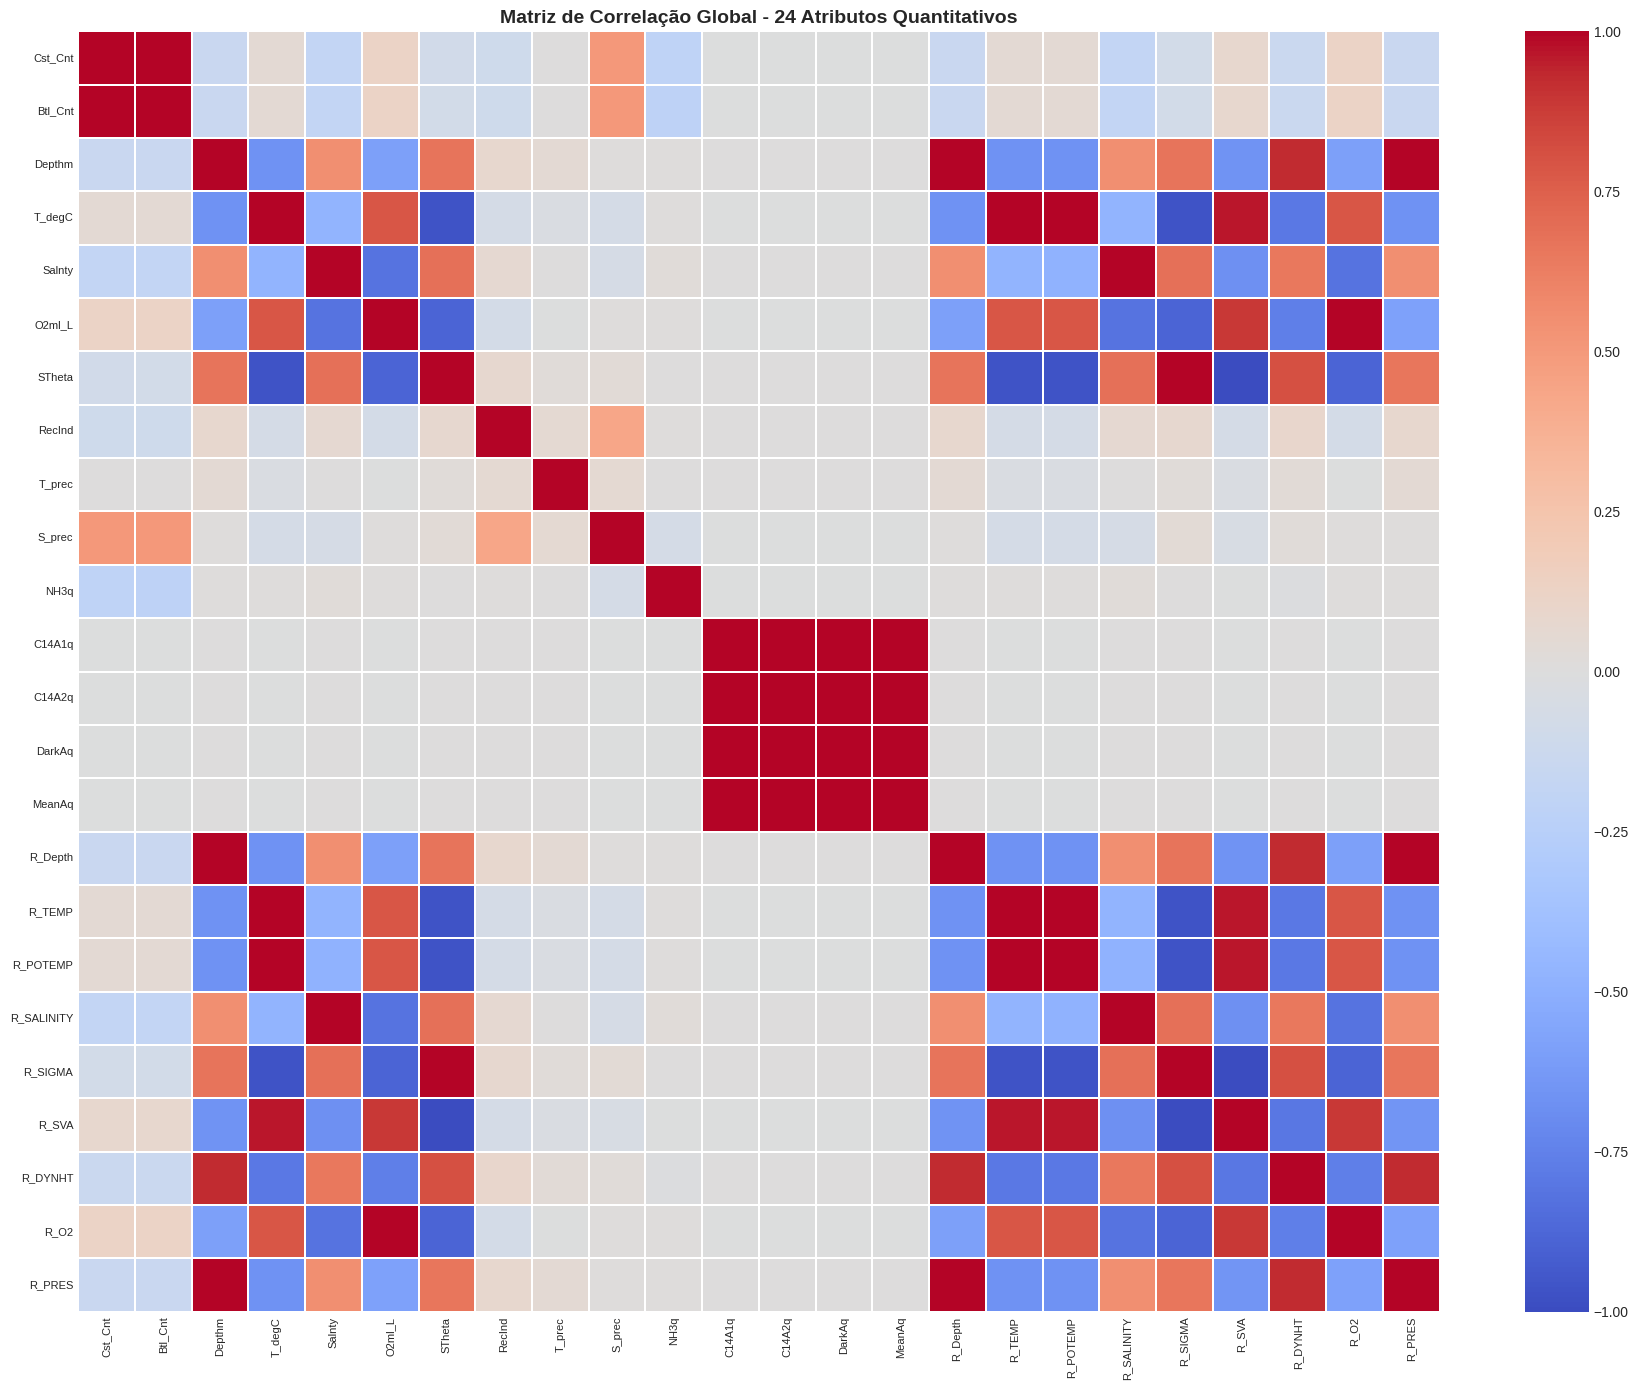

=== TOP 10 CORRELAÇÕES COM A SALINIDADE ('Salnty') ===
R_SALINITY    1.000000
STheta        0.680948
R_SIGMA       0.680887
R_DYNHT       0.653395
R_Depth       0.554513
Depthm        0.554513
R_PRES        0.553294
RecInd        0.065992
NH3q          0.025469
C14A2q        0.004450
Name: Salnty, dtype: float64


In [26]:
# [Célula Extra] Matriz de Correlação de Todos os Atributos Quantitativos

# 1. Selecionar apenas colunas numéricas (float e int)
df_numerico = df.select_dtypes(include=['float64', 'int64'])

# 2. Filtrar colunas que tenham pelo menos 50% de dados preenchidos (evita colunas vazias)
colunas_validas = df_numerico.columns[df_numerico.isnull().mean() < 0.2]
df_filtrado = df_numerico[colunas_validas].dropna()

# 3. Calcular a matriz de correlação de Pearson
matriz_corr_completa = df_filtrado.corr()

# 4. Plotar o Mapa de Calor (Heatmap)
plt.figure(figsize=(18, 14))
sns.heatmap(
    matriz_corr_completa,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.1,
    annot=False  # Desativado por padrão pelo alto volume de colunas
)

plt.title(f'Matriz de Correlação Global - {len(colunas_validas)} Atributos Quantitativos', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# 5. Exibir as 10 maiores correlações (positivas e negativas) com a Salinidade (Salnty)
print("=== TOP 10 CORRELAÇÕES COM A SALINIDADE ('Salnty') ===")
corr_salnty = matriz_corr_completa['Salnty'].drop('Salnty').sort_values(ascending=False)
print(corr_salnty.head(10))